# Australian Domestic Airline Reliability & Market Recovery

**Business question:** which domestic airlines actually get you there on time, which
routes never recovered their pre-COVID capacity, and did the 2024 collapse of
budget carrier Bonza make the routes it used to fly less competitive?

**Approach:** the raw BITRE (Bureau of Infrastructure and Transport Research
Economics) monthly on-time performance data is loaded into **Google BigQuery**
(cloud data warehouse), and all analysis — CTEs, `RANK()`, `LAG()`, and analytic
window functions with `QUALIFY` — runs as SQL directly against it (see
`sql/03_business_analysis.sql`). Python here only executes those queries and
charts the results; a **Power BI** dashboard connects live to the same BigQuery
tables for the interactive view.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.cloud import bigquery
from pathlib import Path

client = bigquery.Client(project="airline-ontime-analytics")

def query(sql):
    return client.query(sql).result().to_dataframe()

IMAGES = Path("images")
IMAGES.mkdir(exist_ok=True)

# Validated categorical / sequential palette (see dataviz skill, references/palette.md)
BLUE, ORANGE, AQUA, YELLOW, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Q1. National capacity trend, 2004–2026

Total monthly domestic sectors flown across all airlines and routes, with a
12-month moving average (`AVG() OVER (... ROWS BETWEEN 11 PRECEDING AND CURRENT
ROW)`) to smooth seasonality. This sets the scene for everything that follows —
the COVID collapse and the shape of the recovery.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


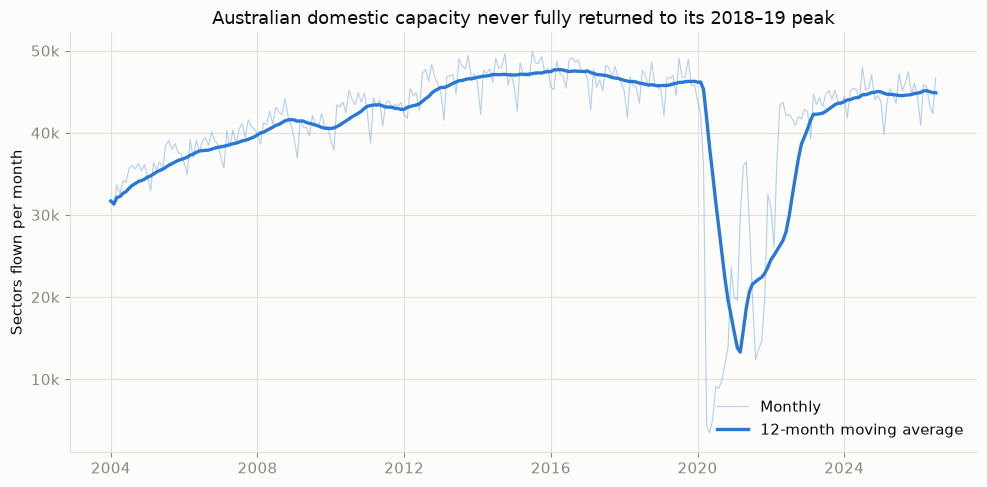

In [2]:
q1 = query('''
    SELECT
        month_date,
        sectors_flown,
        ROUND(AVG(sectors_flown) OVER (
            ORDER BY month_date ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        )) AS sectors_flown_12mo_avg
    FROM `airline_ontime.flights_monthly`
    WHERE is_all_airlines AND is_national_total
    ORDER BY month_date
''')
q1["month_date"] = pd.to_datetime(q1["month_date"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q1["month_date"], q1["sectors_flown"], color=BLUE, linewidth=0.8, alpha=0.35, label="Monthly")
ax.plot(q1["month_date"], q1["sectors_flown_12mo_avg"], color=BLUE, linewidth=2.4, label="12-month moving average")
ax.annotate("COVID collapse\n(2020–21)", xy=(pd.Timestamp("2020-06-01"), 60000), xytext=(pd.Timestamp("2011-01-01"), 40000),
            fontsize=10, color=MUTED, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_ylabel("Sectors flown per month")
ax.set_title("Australian domestic capacity never fully returned to its 2018–19 peak")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(IMAGES / "q1_national_capacity_trend.png", dpi=150)
plt.show()

## Q2. National on-time arrival rate, 2015–2025

Year-over-year change via `LAG()` isolates the single most dramatic finding in
the dataset: punctuality didn't just dip during COVID lockdowns (traffic was
lighter, so what little flew ran on time) — it **collapsed** the moment travel
reopened at scale.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


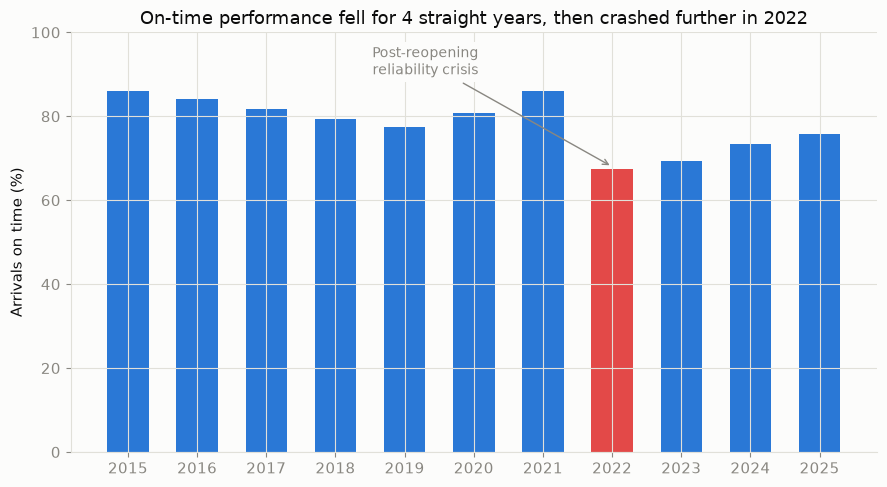

In [3]:
q2 = query('''
    WITH yearly AS (
        SELECT year,
               ROUND(100.0*SUM(arrivals_on_time)/NULLIF(SUM(sectors_flown),0),1) AS on_time_rate_pct
        FROM `airline_ontime.flights_monthly`
        WHERE is_all_airlines AND NOT is_national_total AND year BETWEEN 2015 AND 2025
        GROUP BY year
    )
    SELECT year, on_time_rate_pct,
           ROUND(on_time_rate_pct - LAG(on_time_rate_pct) OVER (ORDER BY year), 1) AS yoy_change_pp
    FROM yearly ORDER BY year
''')

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if y == 2022 else BLUE for y in q2["year"]]
bars = ax.bar(q2["year"].astype(str), q2["on_time_rate_pct"], color=colors, width=0.6)
ax.annotate("Post-reopening\nreliability crisis", xy=(7, 68), xytext=(4.3, 90),
            fontsize=10, color=MUTED, ha="center",
            bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=2),
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_ylabel("Arrivals on time (%)")
ax.set_ylim(0, 100)
ax.set_title("On-time performance fell for 4 straight years, then crashed further in 2022")
fig.tight_layout()
fig.savefig(IMAGES / "q2_on_time_trend.png", dpi=150)
plt.show()

## Q3. Which airline actually gets you there on time? (2025 ranking)

`RANK()` over each airline's 2025 arrival on-time rate, restricted to carriers
with 1,000+ sectors flown so a low-volume regional operator's noisy small-sample
rate can't distort the ranking.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


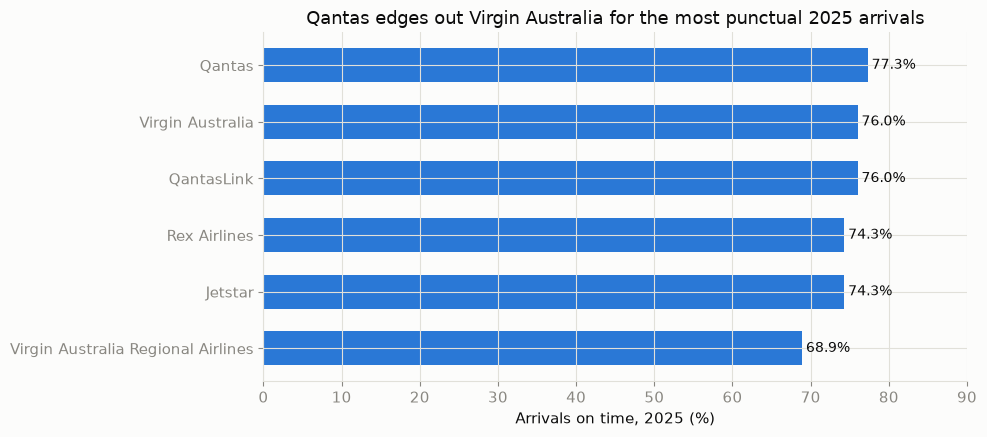

In [4]:
q3 = query('''
    WITH airline_year AS (
        SELECT airline,
               SUM(sectors_flown) AS total_flown,
               ROUND(100.0*SUM(arrivals_on_time)/NULLIF(SUM(sectors_flown),0),1) AS on_time_rate_pct
        FROM `airline_ontime.flights_monthly`
        WHERE year = 2025 AND NOT is_all_airlines AND NOT is_national_total
        GROUP BY airline
    )
    SELECT airline, total_flown, on_time_rate_pct,
           RANK() OVER (ORDER BY on_time_rate_pct DESC) AS reliability_rank
    FROM airline_year
    WHERE total_flown >= 1000
    ORDER BY reliability_rank
''')

fig, ax = plt.subplots(figsize=(10, 4.5))
q3_sorted = q3.sort_values("on_time_rate_pct")
ax.barh(q3_sorted["airline"], q3_sorted["on_time_rate_pct"], color=BLUE, height=0.6)
for y, v in enumerate(q3_sorted["on_time_rate_pct"]):
    ax.text(v + 0.5, y, f"{v}%", va="center", fontsize=10, color=INK)
ax.set_xlabel("Arrivals on time, 2025 (%)")
ax.set_xlim(0, 90)
ax.set_title("Qantas edges out Virgin Australia for the most punctual 2025 arrivals", fontsize=13)
fig.tight_layout()
fig.savefig(IMAGES / "q3_airline_reliability_2025.png", dpi=150)
plt.show()

## Q4–Q5. Which routes recovered — and which never did

Comparing each route's average monthly flights in 2019 (pre-COVID baseline)
against 2025, restricted to routes with at least 20 flights/month in 2019 so
tiny routes don't dominate a percentage-based ranking. Regional routes were hit
hardest and stayed down; several **leisure/holiday routes now fly more than
before COVID** — a genuine domestic tourism boom, not just a recovery.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


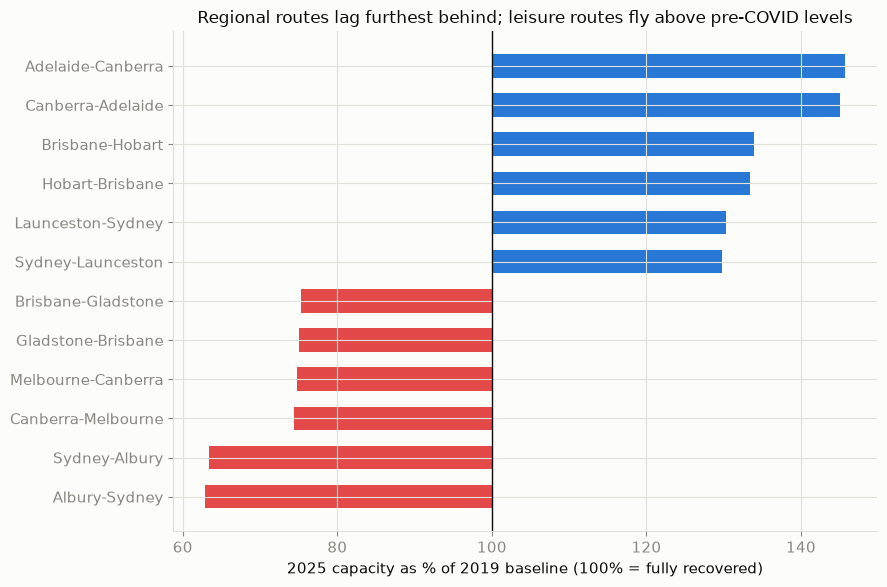

In [5]:
q4 = query('''
    WITH route_year AS (
        SELECT route, year, AVG(sectors_flown) AS avg_monthly_flown
        FROM `airline_ontime.flights_monthly`
        WHERE is_all_airlines AND NOT is_national_total AND year IN (2019, 2025)
        GROUP BY route, year
    ),
    pivoted AS (
        SELECT route,
               MAX(IF(year=2019, avg_monthly_flown, NULL)) AS avg_2019,
               MAX(IF(year=2025, avg_monthly_flown, NULL)) AS avg_2025
        FROM route_year GROUP BY route
    )
    SELECT route, ROUND(avg_2019,1) AS avg_monthly_flights_2019, ROUND(avg_2025,1) AS avg_monthly_flights_2025,
           ROUND(100.0*avg_2025/avg_2019,1) AS pct_of_2019_capacity,
           RANK() OVER (ORDER BY avg_2025/avg_2019 ASC) AS worst_recovery_rank
    FROM pivoted
    WHERE avg_2019 >= 20 AND avg_2025 IS NOT NULL
    ORDER BY pct_of_2019_capacity ASC LIMIT 10
''')

q5 = query('''
    WITH route_year AS (
        SELECT route, year, AVG(sectors_flown) AS avg_monthly_flown
        FROM `airline_ontime.flights_monthly`
        WHERE is_all_airlines AND NOT is_national_total AND year IN (2019, 2025)
        GROUP BY route, year
    ),
    pivoted AS (
        SELECT route,
               MAX(IF(year=2019, avg_monthly_flown, NULL)) AS avg_2019,
               MAX(IF(year=2025, avg_monthly_flown, NULL)) AS avg_2025
        FROM route_year GROUP BY route
    )
    SELECT route, ROUND(avg_2019,1) AS avg_monthly_flights_2019, ROUND(avg_2025,1) AS avg_monthly_flights_2025,
           ROUND(100.0*avg_2025/avg_2019,1) AS pct_of_2019_capacity
    FROM pivoted
    WHERE avg_2019 >= 20 AND avg_2025 IS NOT NULL
    ORDER BY pct_of_2019_capacity DESC LIMIT 10
''')

combined = pd.concat([
    q5.nlargest(6, "pct_of_2019_capacity").assign(group="Grew beyond 2019"),
    q4.nsmallest(6, "pct_of_2019_capacity").assign(group="Worst recovery"),
]).sort_values("pct_of_2019_capacity")

fig, ax = plt.subplots(figsize=(9, 6))
colors = [BLUE if v >= 100 else RED for v in combined["pct_of_2019_capacity"]]
ax.barh(combined["route"], combined["pct_of_2019_capacity"] - 100, left=100, color=colors, height=0.6)
ax.axvline(100, color=INK, linewidth=1)
ax.set_xlabel("2025 capacity as % of 2019 baseline (100% = fully recovered)")
ax.set_title("Regional routes lag furthest behind; leisure routes fly above pre-COVID levels", fontsize=12)
fig.tight_layout()
fig.savefig(IMAGES / "q4_q5_route_recovery.png", dpi=150)
plt.show()

## Q6. Routes that vanished entirely

Set difference (`EXCEPT DISTINCT`) between the routes flown in 2019 and those
flown in 2025 — a harder floor than "reduced capacity": these routes had
**scheduled commercial air service in 2019 and have none in 2025.**

In [6]:
q6 = query('''
    SELECT route
    FROM `airline_ontime.flights_monthly`
    WHERE is_all_airlines AND NOT is_national_total AND year=2019
    GROUP BY route
    EXCEPT DISTINCT
    SELECT route
    FROM `airline_ontime.flights_monthly`
    WHERE is_all_airlines AND NOT is_national_total AND year=2025
    GROUP BY route
    ORDER BY route
''')
print(f"{len(q6)} routes flown in 2019 have no service at all in 2025:")
q6

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


18 routes flown in 2019 have no service at all in 2025:


,route
0,Alice Springs-Darwin
1,Armidale-Sydney
2,Ayers Rock-Sydney
3,Brisbane-Bundaberg
4,Bundaberg-Brisbane
5,Darwin-Alice Springs
6,Darwin-Sydney
7,Geraldton-Perth
8,Perth-Geraldton
9,Proserpine-Sydney


## Q7. Market concentration across competitive routes, 2025

HHI (Herfindahl-Hirschman Index — the sum of each competitor's squared market
share; US antitrust regulators treat >2,500 as "highly concentrated") for every
route with at least 500 sectors/year, so the ranking isn't dominated by routes
too thin to draw a competition conclusion from.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


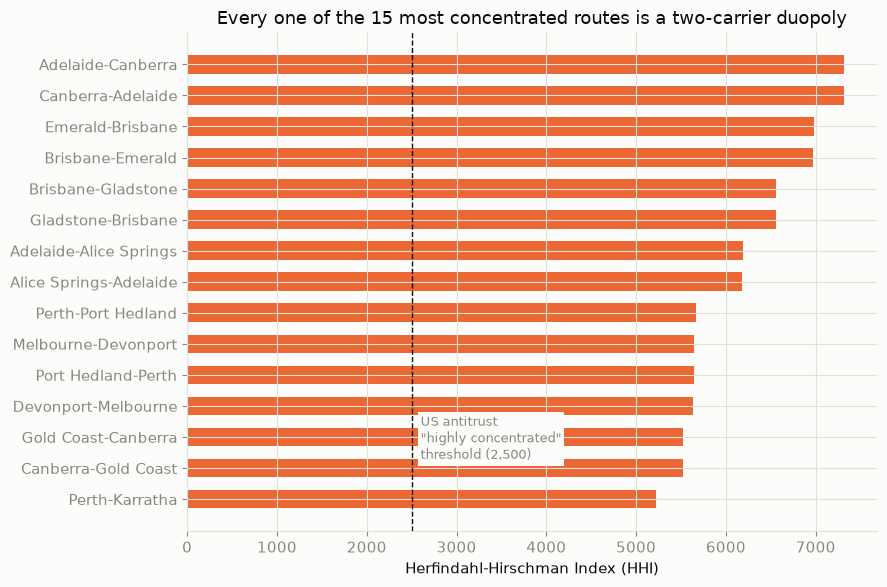

In [7]:
q7 = query('''
    WITH route_airline AS (
        SELECT route, airline, SUM(sectors_flown) AS flown
        FROM `airline_ontime.flights_monthly`
        WHERE year=2025 AND NOT is_all_airlines AND NOT is_national_total
        GROUP BY route, airline HAVING flown > 0
    ),
    shares AS (
        SELECT route, airline, flown,
               SUM(flown) OVER (PARTITION BY route) AS route_total,
               COUNT(*) OVER (PARTITION BY route) AS n_airlines
        FROM route_airline
        QUALIFY route_total >= 500
    )
    SELECT route, ANY_VALUE(n_airlines) AS n_airlines,
           ROUND(SUM(POW(100.0*flown/route_total,2))) AS hhi,
           ROUND(MAX(100.0*flown/route_total),1) AS top_airline_share_pct
    FROM shares GROUP BY route ORDER BY hhi DESC LIMIT 15
''')

fig, ax = plt.subplots(figsize=(9, 6))
q7_sorted = q7.sort_values("hhi")
ax.barh(q7_sorted["route"], q7_sorted["hhi"], color=ORANGE, height=0.6)
ax.axvline(2500, color=INK, linewidth=1, linestyle="--")
ax.text(2600, 1.3, "US antitrust\n\"highly concentrated\"\nthreshold (2,500)", fontsize=9, color=MUTED,
        bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=2))
ax.set_xlabel("Herfindahl-Hirschman Index (HHI)")
ax.set_title("Every one of the 15 most concentrated routes is a two-carrier duopoly", fontsize=13)
fig.tight_layout()
fig.savefig(IMAGES / "q7_market_concentration.png", dpi=150)
plt.show()

## Q8. Case study — did Bonza's 2024 collapse concentrate its former routes?

Budget carrier Bonza flew only 6 routes before entering administration in April
2024. Comparing each of those routes' competitive structure in 2023 (Bonza
flying) against 2025 (Bonza gone) isolates the effect of one airline's exit,
holding the routes themselves constant.

C:\Users\alejo\Mastermind_projects\Portfolio-Data-Analysis\.venv_setup\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


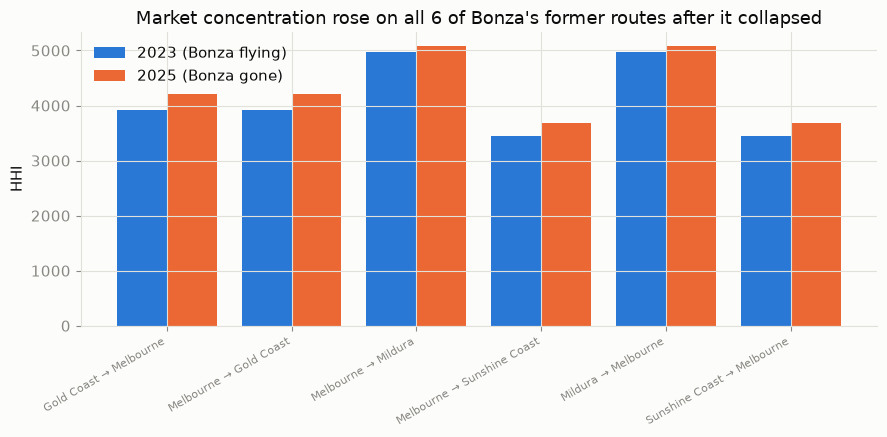

In [8]:
q8 = query('''
    WITH bonza_routes AS (
        SELECT DISTINCT route FROM `airline_ontime.flights_monthly`
        WHERE airline = 'Bonza' AND NOT is_national_total
    ),
    route_airline_year AS (
        SELECT f.route, f.year, f.airline, SUM(f.sectors_flown) AS flown
        FROM `airline_ontime.flights_monthly` f
        JOIN bonza_routes b ON f.route = b.route
        WHERE f.year IN (2023, 2025) AND NOT f.is_all_airlines AND NOT f.is_national_total
        GROUP BY f.route, f.year, f.airline HAVING flown > 0
    ),
    shares AS (
        SELECT route, year, airline, flown,
               SUM(flown) OVER (PARTITION BY route, year) AS route_total,
               COUNT(*) OVER (PARTITION BY route, year) AS n_airlines
        FROM route_airline_year
    )
    SELECT route, year, ANY_VALUE(n_airlines) AS n_airlines, ANY_VALUE(route_total) AS total_sectors_flown,
           ROUND(SUM(POW(100.0*flown/route_total,2))) AS hhi,
           ROUND(MAX(100.0*flown/route_total),1) AS top_airline_share_pct
    FROM shares GROUP BY route, year ORDER BY route, year
''')

pivot = q8.pivot(index="route", columns="year", values="hhi")
fig, ax = plt.subplots(figsize=(9, 4.5))
routes = pivot.index.str.replace("-", " \u2192 ")
x = range(len(routes))
ax.bar([i - 0.2 for i in x], pivot[2023], width=0.4, color=BLUE, label="2023 (Bonza flying)")
ax.bar([i + 0.2 for i in x], pivot[2025], width=0.4, color=ORANGE, label="2025 (Bonza gone)")
ax.set_xticks(list(x))
ax.set_xticklabels(routes, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("HHI")
ax.set_title("Market concentration rose on all 6 of Bonza's former routes after it collapsed")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMAGES / "q8_bonza_case_study.png", dpi=150)
plt.show()

## Summary of headline findings

See `executive_summary.md` and the main `README.md` for the full business
write-up, findings table and recommendations.